# Обнаружение болезни паркинсона с помощью XGBoost

Импортируем библиотеки и модули

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import os
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score

In [ ]:
#@title Анализ датасета
df = pd.read_table('/content/parkinsons.data', sep=',')
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [ ]:
#@title Выводим названия всех столбцов DataFrame.
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [ ]:
#@title Проверяем наличие дубликатов строк в DataFrame и суммируем их количество.
df.duplicated().sum()

np.int64(0)

In [ ]:
# Подсчитываем количество уникальных значений в столбце 'label'.
df.status.value_counts()

,count
status,
1,147
0,48


# Построение и обучение модели

In [ ]:
X = df.drop(columns=['name', 'status']) # Создаем набор признаков X, исключая столбцы 'name' и 'status'.
y = df.status # Создаем целевую переменную y, содержащую столбец 'status'.

scaler = StandardScaler() # Инициализируем StandardScaler для нормализации данных.
X_scaled = scaler.fit_transform(X) # Применяем нормализацию к признакам X.

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=7, stratify=y) # Разделяем данные на обучающую и тестовую выборки, сохраняя пропорции классов.

model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', learning_rate=0.1, max_depth=10, n_estimators=100) # Инициализируем модель XGBoost Classifier с заданными гиперпараметрами.
model.fit(X_train, y_train) # Обучаем модель на обучающих данных.

predictions = model.predict(X_test) # Делаем предсказания на тестовой выборке.
accuracy = accuracy_score(y_test, predictions) # Вычисляем точность модели.
print(f'Accuracy: {accuracy:.2%}') # Выводим точность модели.

print(classification_report(y_test, predictions)) # Выводим подробный отчет по классификации (точность, полнота, F1-мера).
print(confusion_matrix(y_test, predictions)) # Выводим матрицу ошибок.

Accuracy: 97.44%
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.97      1.00      0.98        29

    accuracy                           0.97        39
   macro avg       0.98      0.95      0.97        39
weighted avg       0.98      0.97      0.97        39

[[ 9  1]
 [ 0 29]]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:40:29] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# Визиализируем матрицу ошибок

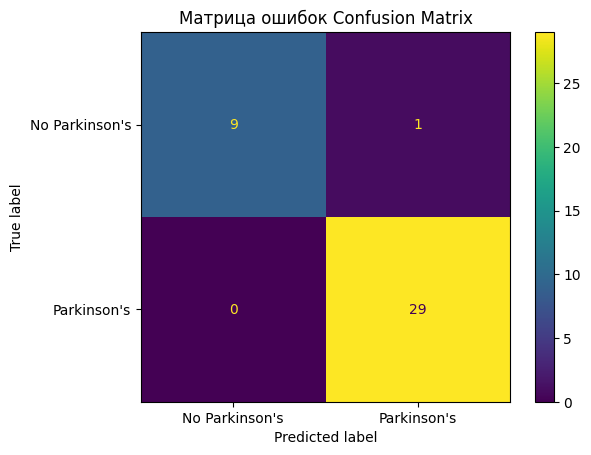

In [ ]:
cm = confusion_matrix(y_test, predictions)   # Вычисление матрицы ошибок на основе фактических и предсказанных значений.
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Parkinson\'s', 'Parkinson\'s'])   # Создание объекта для отображения матрицы ошибок, с указанием меток классов.
disp.plot()   # Построение графика матрицы ошибок.
plt.title('Матрица ошибок Confusion Matrix')   # Установка заголовка для графика.
plt.show()   # Отображение графика

# Сводка результатов модели

In [ ]:
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy:.2%}')

Accuracy: 97.44%


In [ ]:
precision_score = precision_score(y_test, model.predict(X_test))
print(f'precision_score: {precision_score:.2%}')

precision_score: 96.67%


In [ ]:
f1 = f1_score(y_test, model.predict(X_test))
print(f'F1-score: {f1:.2%}')

F1-score: 98.31%


In [ ]:
recall_score = recall_score(y_test, model.predict(X_test))
print(f'recall_score: {recall_score:.2%}')

recall_score: 100.00%


# Анализ важности признаков которые наиболее значимы для модели при прогнозировании болезни Паркинсона


In [ ]:
feature_importances = model.feature_importances_ # Извлекаем важность признаков из обученной модели XGBoost.
feature_names = X.columns # Получаем названия всех признаков из DataFrame X.

feature_importances_df = pd.DataFrame({ # Создаем новый DataFrame для хранения важности признаков.
    'Feature': feature_names, # Столбец для названий признаков.
    'Importance': feature_importances # Столбец для значений важности признаков.
})

feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False) # Сортируем DataFrame по важности признаков в порядке убывания.
print(feature_importances_df.head(10)) # Выводим первые 10 наиболее важных признаков.

             Feature  Importance
21               PPE    0.148243
18           spread1    0.143381
12          MDVP:APQ    0.096442
10      Shimmer:APQ3    0.084843
2       MDVP:Flo(Hz)    0.071355
14               NHR    0.052548
9   MDVP:Shimmer(dB)    0.048136
0        MDVP:Fo(Hz)    0.047528
8       MDVP:Shimmer    0.047005
20                D2    0.037895


## Резюме:

### Основные результаты анализа данных

* Из обученной модели XGBoost были успешно извлечены важные объекты и сопоставлены с их названиями.
* Был создан фрейм данных Pandas, в котором названия объектов отображались рядом с их оценками важности, а затем отсортированы в порядке убывания важности.
* Двумя наиболее важными характеристиками, которые были определены, были "PPE" с важностью 0,148243 и "spread1" с важностью 0,143381.



## Визуализируем важность объектов

 График важности признаков, чтобы наглядно представить наиболее значимые характеристики.


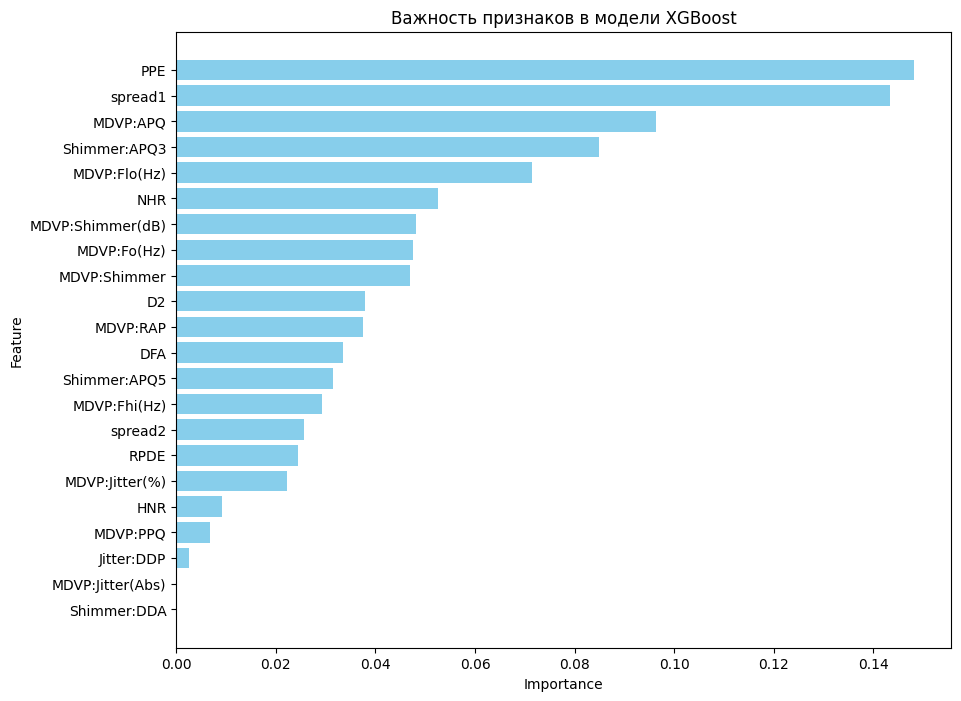

In [ ]:
plt.figure(figsize=(10, 8))
plt.barh(feature_importances_df['Feature'], feature_importances_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Важность признаков в модели XGBoost')
plt.gca().invert_yaxis() # Сортируем от наиболее важных к наименее важным
plt.show()

# Резюме вывод по модели:
Модель XGBoost продемонстрировала выдающиеся результаты в задаче обнаружения болезни Паркинсона.
Ее общая точность (Accuracy) составила 97.44%, что указывает на то, что почти 97.5% всех прогнозов модели были верными. Это очень высокий показатель, говорящий о надежности модели в целом.
\
\
При рассмотрении более детальных метрик для класса 1 (наличие болезни Паркинсона), модель достигла точности (Precision) 96.67%. Это означает, что из всех пациентов, которым модель предсказала болезнь Паркинсона, 96.67% действительно ею болеют. Очень низкий уровень ложноположительных срабатываний критически важен в медицинских диагностических моделях, поскольку позволяет избежать ненужных стрессов и дальнейших обследований для здоровых людей.
\
\
Наиболее впечатляющим показателем является полнота (Recall), которая составила 100.00%. Это означает, что модель успешно выявила всех пациентов, страдающих болезнью Паркинсона, из тестового набора данных. Отсутствие ложноотрицательных срабатываний крайне важно, так как пропуск диагноза может иметь серьезные последствия для здоровья пациента.
\
\
Наконец, F1-мера (F1-score), которая является гармоническим средним между точностью и полнотой, составила 98.31%. Эта метрика хорошо сбалансирована и отражает общую эффективность модели, когда важны как точность, так и полнота.
\
\
Таким образом, модель XGBoost не только точно классифицирует пациентов, но и чрезвычайно эффективно обнаруживает всех носителей болезни, что делает ее очень перспективным инструментом для первичной диагностики болезни Паркинсона.